# Exploratory Data Analysis (EDA)

## Global Superstore Sales Dataset

### Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on the Global Superstore Sales dataset using statistical analysis and data visualization.

The analysis aims to identify sales trends, customer behavior, regional performance, product performance, and other meaningful business insights that can support data-driven decision making.

# Table of Contents

1. Import Libraries
2. Load Dataset
3. Dataset Overview
4. Data Quality Check
5. Statistical Summary
6. Univariate Analysis
7. Bivariate Analysis
8. Correlation Analysis
9. Time Series Analysis
10. Business Insights
11. Conclusion

In [1]:
# Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


# Graph Settings
plt.rcParams["figure.figsize"] = (10,6)



In [2]:
# Load Dataset

try:
    df = pd.read_csv("data/superstore.csv", encoding="latin1")
    print("Dataset Loaded Successfully!")
except Exception as e:
    print("Error loading dataset:", e)

df.head()

Dataset Loaded Successfully!


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Step 1: Dataset Overview

Before performing any analysis, it is important to understand the structure, size, and quality of the dataset.

In this section, we will examine:
- Dataset dimensions
- Column names
- Data types
- Summary statistics
- Missing values
- Duplicate records

In [3]:
# Dataset Shape

print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 9994
Number of Columns : 21


In [4]:
# Column Names

print("Columns in Dataset:\n")

for column in df.columns:
    print(column)

Columns in Dataset:

Row ID
Order ID
Order Date
Ship Date
Ship Mode
Customer ID
Customer Name
Segment
Country
City
State
Postal Code
Region
Product ID
Category
Sub-Category
Product Name
Sales
Quantity
Discount
Profit


In [5]:
# First and Last Five Records

print("First Five Records")
display(df.head())

print("\nLast Five Records")
display(df.tail())

First Five Records


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164



Last Five Records


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,5/4/2017,5/9/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [6]:
# Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [7]:
# Statistical Summary
print("Numerical Summary")
display(df.describe())
print("Categorical Summary")
display(df.describe(include=["object"]))

Numerical Summary


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


Categorical Summary


C:\Users\SarthakVats\AppData\Local\Temp\ipykernel_15892\4011153227.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include=["object"]))


,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,1237,1334,4,793,793,3,1,531,49,4,1862,3,17,1850
top,CA-2017-100111,9/5/2016,12/16/2015,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,38,35,5968,37,37,5191,9994,915,2001,3203,19,6026,1523,48


In [8]:
# Missing Values

missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": (df.isnull().sum()/len(df)*100).round(2)
})

missing_values.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage (%)
Row ID,0,0.0
Order ID,0,0.0
Order Date,0,0.0
Ship Date,0,0.0
Ship Mode,0,0.0
Customer ID,0,0.0
Customer Name,0,0.0
Segment,0,0.0
Country,0,0.0
City,0,0.0


In [9]:
# Duplicate Records

duplicates = df.duplicated().sum()

print("Total Duplicate Records :", duplicates)

Total Duplicate Records : 0


In [10]:
# Data Types

dtype_df = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str)
})

dtype_df

,Column,Data Type
Row ID,Row ID,int64
Order ID,Order ID,str
Order Date,Order Date,str
Ship Date,Ship Date,str
Ship Mode,Ship Mode,str
Customer ID,Customer ID,str
Customer Name,Customer Name,str
Segment,Segment,str
Country,Country,str
City,City,str


# Step 2: Data Preparation

Before performing Exploratory Data Analysis (EDA), the dataset needs to be prepared.

The following preprocessing steps are performed:

- Convert date columns into datetime format
- Verify data types
- Create additional date-based features for trend analysis

In [11]:
# Convert Date Columns

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

print("Date columns converted successfully!")

print("\nOrder Date:", df["Order Date"].dtype)
print("Ship Date :", df["Ship Date"].dtype)

Date columns converted successfully!

Order Date: datetime64[us]
Ship Date : datetime64[us]


In [12]:
# Date Feature Engineering

df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month_name()
df["Order Quarter"] = df["Order Date"].dt.quarter

print("New Features Created Successfully!")

df[["Order Date","Order Year","Order Month","Order Quarter"]].head()

New Features Created Successfully!


,Order Date,Order Year,Order Month,Order Quarter
0,2016-11-08,2016,November,4
1,2016-11-08,2016,November,4
2,2016-06-12,2016,June,2
3,2015-10-11,2015,October,4
4,2015-10-11,2015,October,4


In [13]:
# Updated Data Types

dtype_df = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str)
})

dtype_df

,Column,Data Type
Row ID,Row ID,int64
Order ID,Order ID,str
Order Date,Order Date,datetime64[us]
Ship Date,Ship Date,datetime64[us]
Ship Mode,Ship Mode,str
Customer ID,Customer ID,str
Customer Name,Customer Name,str
Segment,Segment,str
Country,Country,str
City,City,str


# Step 3: Univariate Analysis

Univariate analysis focuses on understanding the distribution of individual variables.

This section explores:

- Sales Distribution
- Profit Distribution
- Product Categories
- Customer Segments
- Regional Distribution

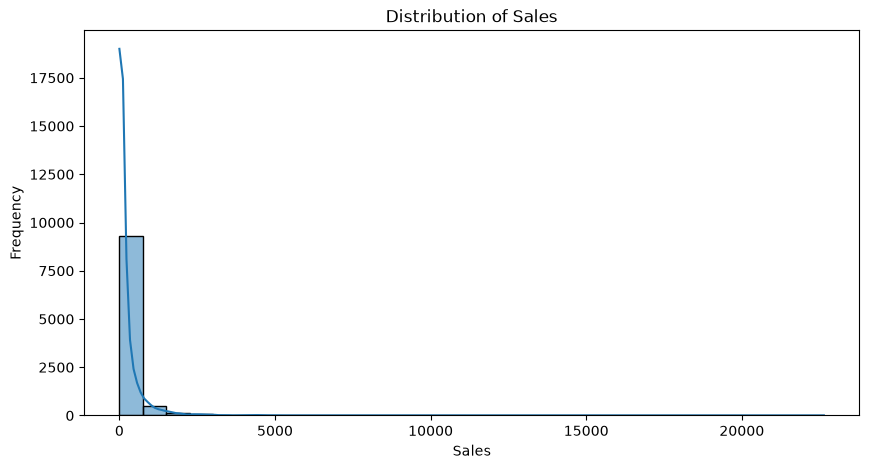

In [14]:
# Sales Distribution

plt.figure(figsize=(10,5))

sns.histplot(df["Sales"], bins=30, kde=True)

plt.title("Distribution of Sales")

plt.xlabel("Sales")

plt.ylabel("Frequency")

plt.show()

### Observation

- Most sales transactions are of relatively low value.
- A few transactions have exceptionally high sales.
- The distribution is positively skewed.

### Insight

The company receives a large number of small orders, while high-value orders occur less frequently.

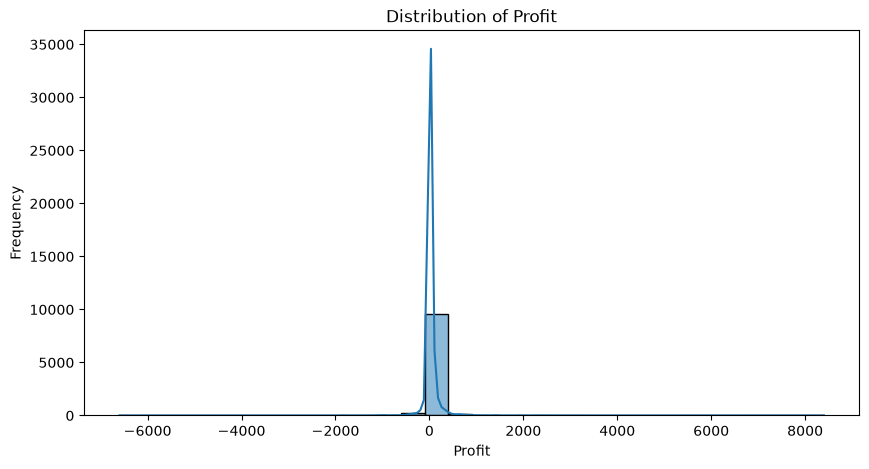

In [15]:
# Profit Distribution

plt.figure(figsize=(10,5))

sns.histplot(df["Profit"], bins=30, kde=True)

plt.title("Distribution of Profit")

plt.xlabel("Profit")

plt.ylabel("Frequency")

plt.show()

### Observation

- Profit values are concentrated around lower values.
- Some transactions result in negative profit.
- A few highly profitable transactions are present.

### Insight

Although most orders generate profit, certain products or discounts lead to financial losses.

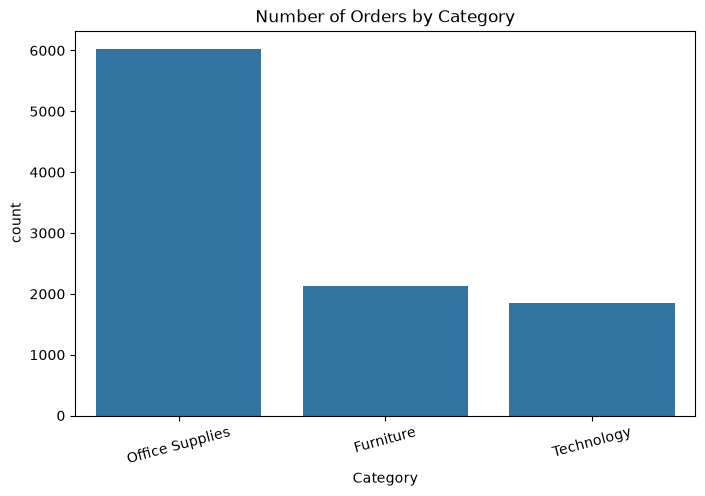

In [16]:
# Product Category Distribution

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Category",
    order=df["Category"].value_counts().index
)

plt.title("Number of Orders by Category")

plt.xticks(rotation=15)

plt.show()

### Observation

- Office Supplies has the highest number of orders among all product categories.
- Furniture is the second most ordered category, followed by Technology.
- The number of orders varies noticeably across the three product categories.

### Insight

Office Supplies contributes the largest share of customer orders, indicating consistently high demand. Although Technology has fewer orders, it may still contribute significantly to revenue, which can be explored in later analyses.

# Step 4: Customer Segment Analysis

Customer segmentation helps identify which group of customers contributes the most to business activity.

The dataset contains three customer segments:
- Consumer
- Corporate
- Home Office

This analysis compares the number of orders placed by each customer segment.

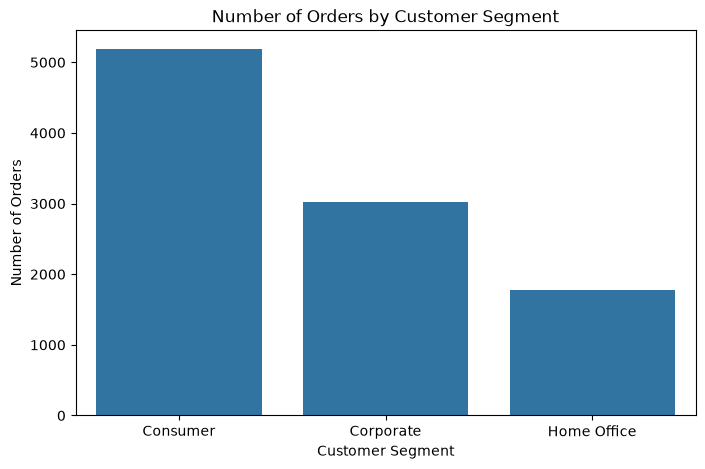

In [17]:
# Customer Segment Distribution

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Segment",
    order=df["Segment"].value_counts().index
)

plt.title("Number of Orders by Customer Segment")

plt.xlabel("Customer Segment")
plt.ylabel("Number of Orders")

plt.show()

### Observation

- The Consumer segment has the highest number of orders.
- The Corporate segment ranks second in terms of order count.
- The Home Office segment contributes the fewest orders.

### Insight

The Consumer segment represents the largest customer base and contributes the highest business activity. This indicates that consumer-focused marketing strategies are likely to have the greatest impact on overall sales.

# Step 5: Regional Analysis

Regional analysis helps compare customer activity across different geographical regions.

This visualization shows the number of orders received from each region.

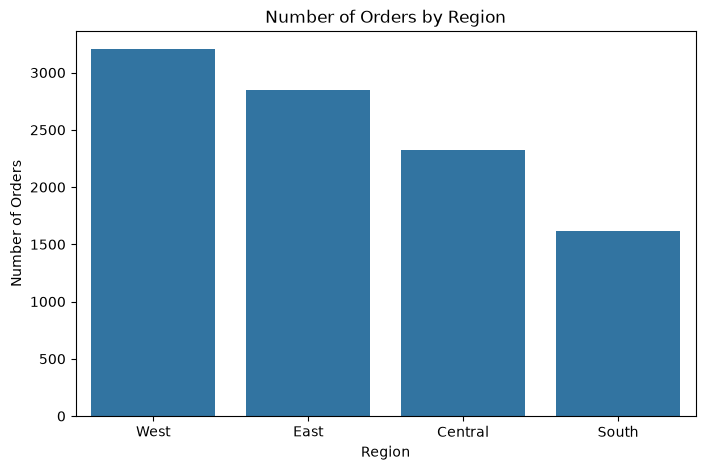

In [18]:
# Orders by Region

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Region",
    order=df["Region"].value_counts().index
)

plt.title("Number of Orders by Region")

plt.xlabel("Region")
plt.ylabel("Number of Orders")

plt.show()

### Observation

- The West region has the highest number of orders.
- The East region is the second-largest contributor.
- The South region records the fewest orders.

### Insight

The West region represents the strongest market in terms of customer orders, while the South region has comparatively lower business activity and may offer opportunities for market expansion.

# Step 6: Shipping Mode Analysis

Shipping mode analysis helps understand customer preferences for delivery methods.

This visualization compares the frequency of each shipping mode.

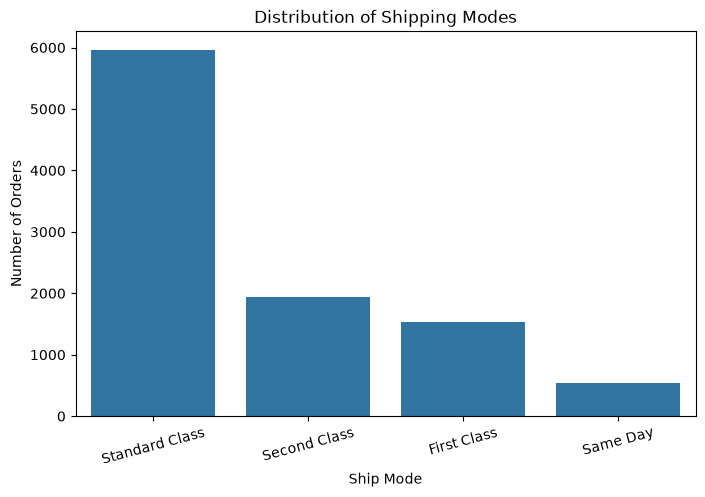

In [19]:
# Ship Mode Distribution

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Ship Mode",
    order=df["Ship Mode"].value_counts().index
)

plt.title("Distribution of Shipping Modes")

plt.xlabel("Ship Mode")
plt.ylabel("Number of Orders")

plt.xticks(rotation=15)

plt.show()

### Observation

- Standard Class is the most frequently used shipping mode.
- Second Class is the second most preferred shipping option, followed by First Class.
- Same Day shipping is used the least among all shipping modes.

### Insight

Most customers prefer Standard Class shipping, suggesting that cost-effective delivery is favored over faster shipping options. Same Day delivery has limited usage, indicating that only a small proportion of customers require urgent delivery services.

# Step 7: Sales vs Profit Analysis

This analysis explores the relationship between sales and profit to understand whether higher sales consistently lead to higher profits.

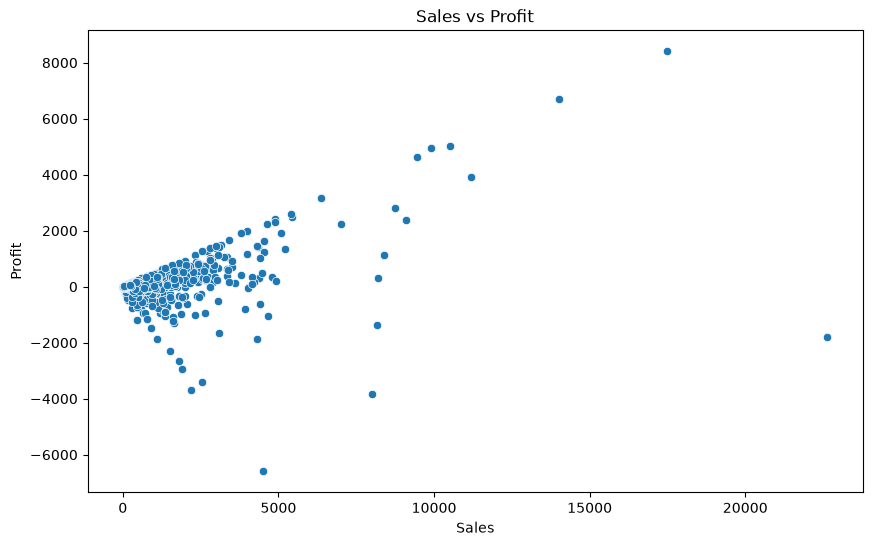

In [20]:
# Sales vs Profit Relationship

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit"
)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.show()

### Observation

- Most transactions involve relatively low sales and low profit values.
- As sales increase, profit generally tends to increase, although some high-sales orders still generate low or negative profit.
- A few transactions have exceptionally high sales and profit, appearing as outliers.

### Insight

Higher sales do not always guarantee higher profitability. Factors such as discounts, product category, and operational costs may reduce profit even for high-value sales.

# Step 8: Discount vs Profit Analysis

Discounts are commonly used to increase sales, but excessive discounts may reduce profitability.

This analysis examines the relationship between discount offered and profit earned.

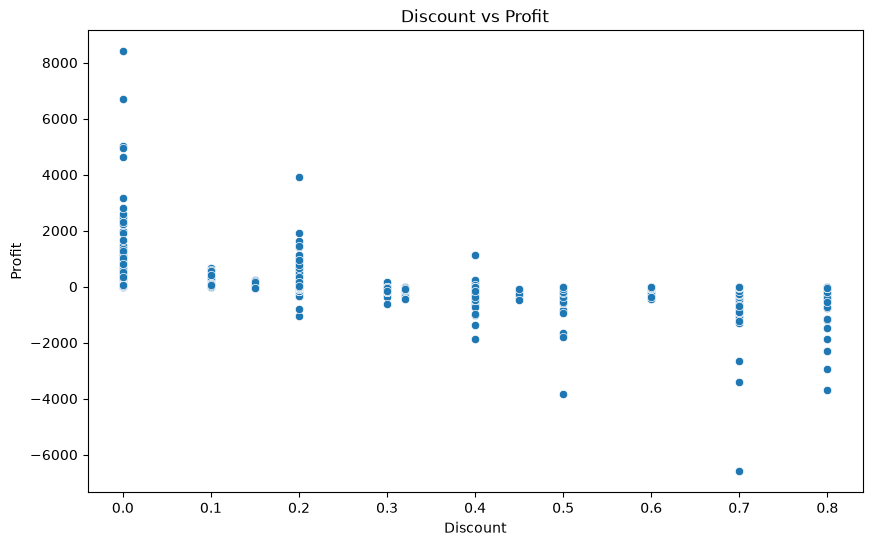

In [21]:
# Discount vs Profit Relationship

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit"
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

### Observation

- Higher discount values are often associated with lower profits.
- Many transactions with large discounts result in negative profit.
- Orders with little or no discount generally show better profitability.

### Insight

Offering excessive discounts can significantly reduce profit margins. Businesses should carefully balance promotional discounts with profitability to avoid financial losses.

# Step 9: Correlation Analysis

A correlation matrix helps identify the strength and direction of relationships between numerical variables.

Positive values indicate a direct relationship, while negative values indicate an inverse relationship.

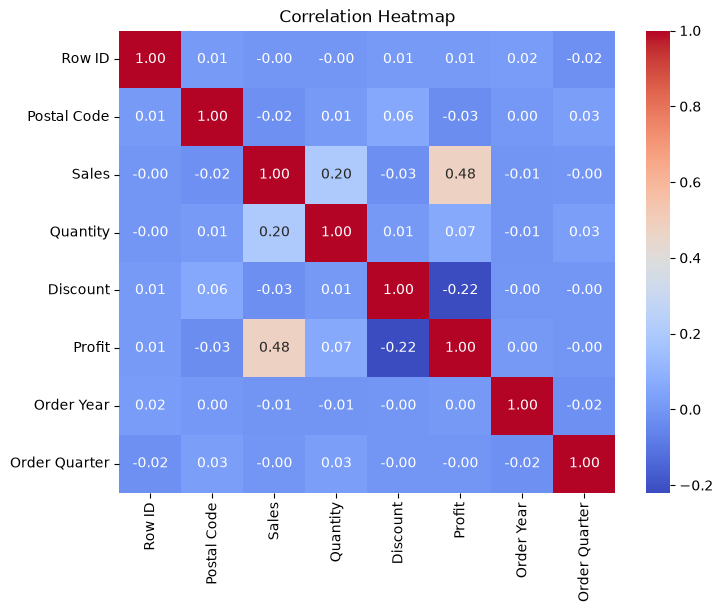

In [22]:
# Correlation Heatmap

numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

- Sales and Profit show a moderate positive correlation.
- Discount has a negative correlation with Profit.
- Quantity has a weak positive relationship with Sales.
- Most numerical variables exhibit weak to moderate correlations.

### Insight

The heatmap indicates that profitability is influenced by multiple factors rather than a single variable. Discount has the most noticeable negative effect on profit, highlighting the importance of effective pricing strategies.

# Step 10: Monthly Sales Trend

Time series analysis helps identify how sales change over time.

This visualization shows the monthly sales trend, allowing us to identify seasonal patterns and business growth.

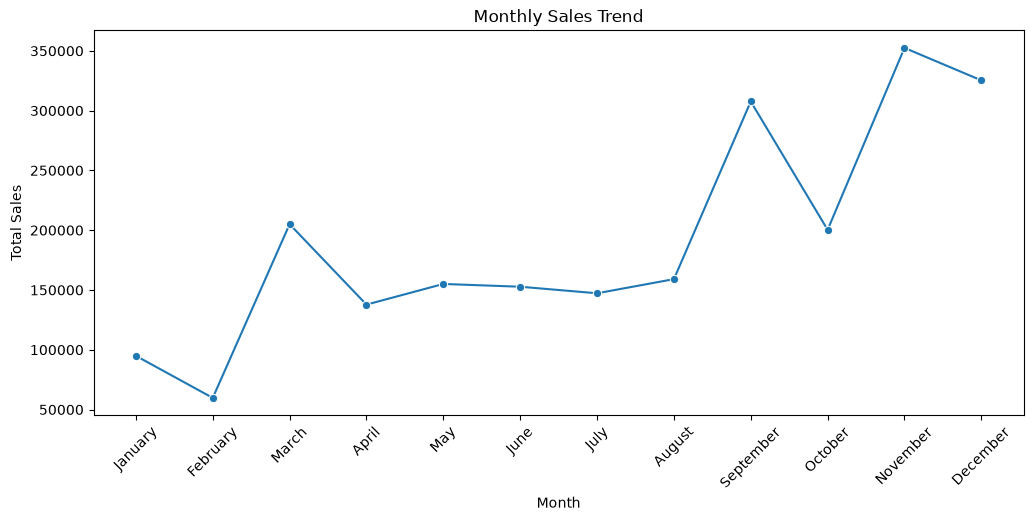

In [23]:
# Monthly Sales Trend

monthly_sales = df.groupby("Order Month")["Sales"].sum()

month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_sales = monthly_sales.reindex(month_order)

plt.figure(figsize=(12,5))

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

### Observation

- Sales remain relatively moderate during the first half of the year.
- A noticeable increase in sales begins from September and continues through December.
- November records the highest monthly sales, while February has the lowest sales.
- The last quarter (October–December) contributes significantly more sales than the earlier months.

### Insight

The business experiences stronger sales performance during the final months of the year, indicating seasonal demand. Marketing campaigns, inventory planning, and promotional activities should be prioritized during this period to maximize revenue.

# Step 11: Year-wise Sales Trend

This analysis examines total sales across different years to understand overall business growth.

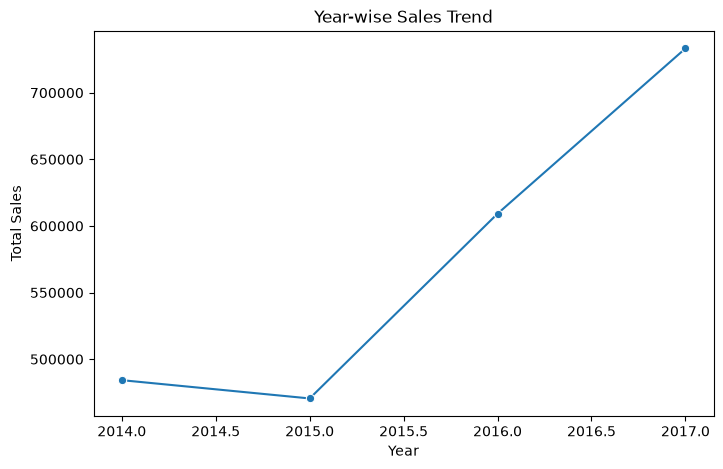

In [24]:
# Year-wise Sales Trend

yearly_sales = df.groupby("Order Year")["Sales"].sum()

plt.figure(figsize=(8,5))

sns.lineplot(
    x=yearly_sales.index,
    y=yearly_sales.values,
    marker="o"
)

plt.title("Year-wise Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.show()

### Observation

- Sales show a slight decline from 2014 to 2015.
- A strong increase in sales is observed in 2016.
- 2017 records the highest annual sales among all four years.
- Overall, the business demonstrates positive growth after 2015.

### Insight

The consistent increase in sales during the later years indicates business expansion and improved customer engagement. The upward trend suggests healthy long-term growth in overall sales performance.

# Step 12: Top 10 States by Sales

This analysis identifies the top-performing states based on total sales.

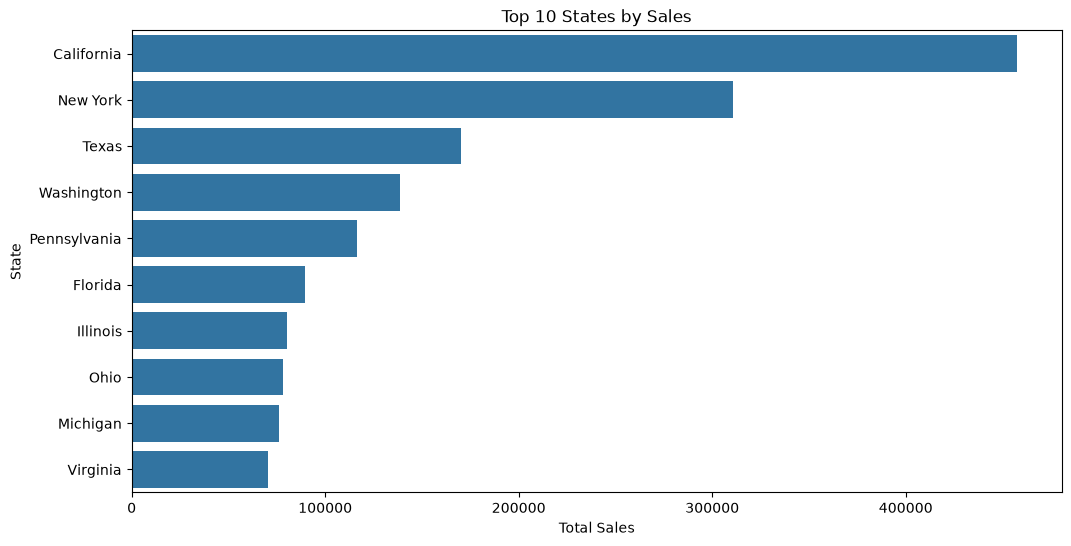

In [25]:
# Top 10 States by Sales

top_states = (
    df.groupby("State")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_states.values,
    y=top_states.index
)

plt.title("Top 10 States by Sales")
plt.xlabel("Total Sales")
plt.ylabel("State")

plt.show()

### Observation

- California generates the highest total sales by a significant margin.
- New York ranks second, followed by Texas.
- The remaining states contribute comparatively lower sales than the top three.
- Sales are concentrated in a few high-performing states.

### Insight

California and New York represent the strongest markets for the business. Focusing marketing efforts, inventory management, and customer retention strategies in these states can further improve overall business performance while identifying growth opportunities in lower-performing regions.

# Step 13: Top 10 Sub-Categories by Profit

This analysis identifies the most profitable product sub-categories.

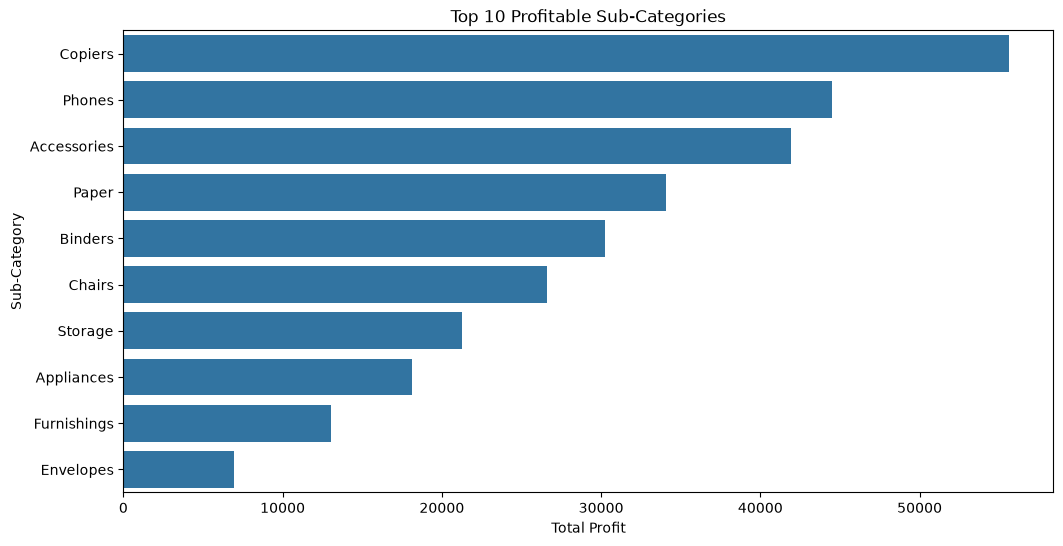

In [26]:
# Top 10 Sub-Categories by Profit

top_profit = (
    df.groupby("Sub-Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_profit.values,
    y=top_profit.index
)

plt.title("Top 10 Profitable Sub-Categories")
plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")

plt.show()

### Observation

- Copiers generate the highest total profit among all sub-categories.
- Phones and Accessories are also highly profitable product groups.
- Envelopes contribute the least profit among the top ten profitable sub-categories.
- Profitability varies considerably across different product sub-categories.

### Insight

Technology-related products, particularly Copiers and Phones, contribute substantially to business profitability. Prioritizing these high-performing product categories can improve overall profit while maintaining a balanced product portfolio.

# Step 14: Key Business Insights

Based on the exploratory data analysis, the following major business insights were identified:

1. The business generated the highest sales during November and December, indicating strong seasonal demand.

2. Sales have shown consistent growth after 2015, with 2017 recording the highest annual sales.

3. California and New York are the strongest revenue-generating states, contributing significantly more sales than other regions.

4. The Consumer segment places the highest number of orders, making it the most valuable customer segment.

5. Office Supplies is the most frequently purchased product category, indicating consistent customer demand.

6. Standard Class is the preferred shipping mode, suggesting customers prioritize economical shipping over faster delivery.

7. Copiers, Phones, and Accessories generate the highest profits, making them important products for business profitability.

8. Higher discounts are associated with lower profits, highlighting the need for optimized discount strategies.

9. Although higher sales generally lead to higher profits, some high-value orders still generate losses, indicating that pricing and discount policies require careful monitoring.

# Step 15: Business Recommendations

Based on the analysis, the following recommendations can improve business performance:

- Increase inventory and promotional campaigns before the holiday season, especially during November and December.

- Focus marketing efforts on high-performing states such as California and New York while identifying growth opportunities in lower-performing regions.

- Strengthen customer retention strategies for the Consumer segment, which contributes the largest share of orders.

- Promote highly profitable product categories such as Copiers, Phones, and Accessories.

- Review discount policies to prevent unnecessary reductions in profit margins.

- Encourage customers to purchase higher-margin products through personalized recommendations and targeted promotions.

- Continue monitoring yearly sales trends to support long-term business planning.

# Step 16: Executive Summary

This Exploratory Data Analysis (EDA) was performed on the Global Superstore dataset containing 9,994 business transactions.

The analysis included:

- Data understanding
- Statistical summary
- Missing value analysis
- Duplicate record analysis
- Data type inspection
- Customer segmentation
- Regional analysis
- Shipping mode analysis
- Sales and profit relationship
- Discount analysis
- Correlation analysis
- Monthly and yearly sales trends
- State-wise sales analysis
- Product profitability analysis

The findings indicate strong business growth, seasonal sales patterns, profitable product categories, and the impact of discounts on profitability. These insights can support better business decision-making and future predictive modeling.

In [28]:
# Dataset Summary

summary = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Total Columns",
        "Missing Values",
        "Duplicate Records",
        "Unique Customers",
        "Unique Products",
        "Regions",
        "Categories",
        "Sub-Categories"
    ],
    "Value": [
        len(df),
        len(df.columns),
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        df["Customer ID"].nunique(),
        df["Product ID"].nunique(),
        df["Region"].nunique(),
        df["Category"].nunique(),
        df["Sub-Category"].nunique()
    ]
})

summary

,Metric,Value
0,Total Rows,9994
1,Total Columns,24
2,Missing Values,0
3,Duplicate Records,0
4,Unique Customers,793
5,Unique Products,1862
6,Regions,4
7,Categories,3
8,Sub-Categories,17


# Step 17: Conclusion

The Exploratory Data Analysis successfully identified important patterns, trends, and relationships within the Global Superstore dataset.

The business demonstrates consistent sales growth, strong seasonal demand, and significant variation across customer segments, regions, and product categories. While higher sales generally contribute to higher profits, discount strategies have a noticeable impact on profitability.

Overall, the dataset provides valuable insights that can support strategic business decisions and serves as a strong foundation for predictive analytics and machine learning applications.